In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss

### 1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция. Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с параметрами test_size = 0.8 и random_state = 241.

In [2]:
df = pd.read_csv('gbm-data.csv')
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

### 2. Обучите GradientBoostingClassifier с параметрами n_estimators=250, verbose=True, random_state=241 и для каждого значения learning_rate из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:
• Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой итерации.

• Преобразуйте полученное предсказание по формуле 1+e−y1_pred, где y_pred — предсказанное значение.

• Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.

In [3]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
res_02 = {'min_loss': np.inf, 'iter': -1}

In [4]:
for lr in learning_rates:
    gb = GradientBoostingClassifier(n_estimators=250, learning_rate=lr, random_state=241, verbose=False)
    gb.fit(X_train, y_train)
    
    test_losses = []
    for y_pred_test in gb.staged_decision_function(X_test):
        proba = 1.0 / (1.0 + np.exp(-y_pred_test))
        test_losses.append(log_loss(y_test, proba))
        
    if lr == 0.2:
        res_02['min_loss'] = min(test_losses)
        res_02['iter'] = np.argmin(test_losses) + 1

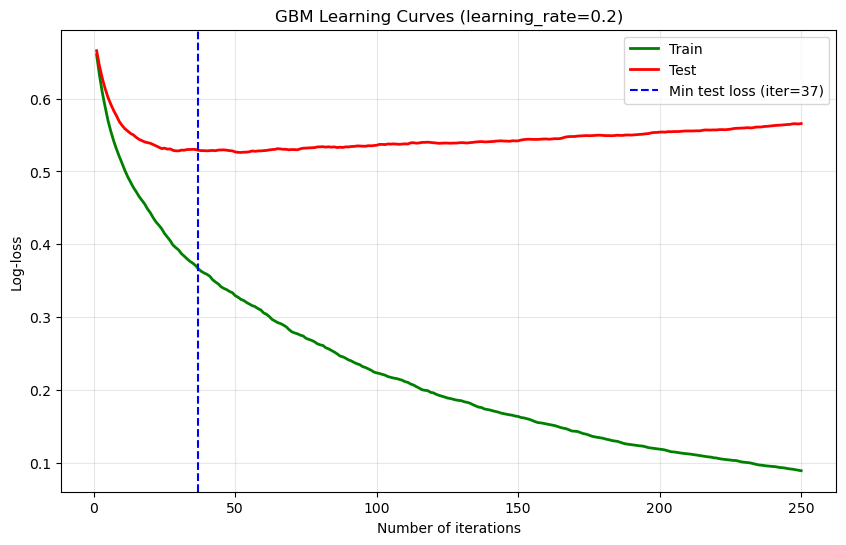

In [5]:
train_losses = []
for y_pred_train in gb.staged_decision_function(X_train):
    proba_train = 1.0 / (1.0 + np.exp(-y_pred_train))
    train_losses.append(log_loss(y_train, proba_train))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 251), train_losses, 'g', linewidth=2, label='Train')
plt.plot(range(1, 251), test_losses, 'r', linewidth=2, label='Test')
plt.axvline(x=res_02['iter'], color='b', linestyle='--', label=f'Min test loss (iter={res_02["iter"]})')
plt.xlabel('Number of iterations')
plt.ylabel('Log-loss')
plt.title(f'GBM Learning Curves (learning_rate={0.2})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
print(f"ответ3: overfitting")

ответ3: overfitting


### 4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

In [10]:
ans4 = f"{res_02['min_loss']:.2f} {res_02['iter']}"
print(ans4)

0.53 37


### 5. На этих же данных обучите RandomForestClassifier с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию. Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции predict_proba. В данном случае брать сигмоиду от оценки вероятности класса не нужно)

In [11]:
rf = RandomForestClassifier(n_estimators=res_02['iter'], random_state=241)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
ans5 = f"{log_loss(y_test, rf_proba):.2f}"
print(f"ответ5: {ans5}")

ответ5: 0.54
